In [2]:
# Ensure local package import works in notebook
import sys
from pathlib import Path

# Add project root (one level up from notebooks/) to sys.path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("sys.path updated with:", PROJECT_ROOT)


sys.path updated with: /home/julian_linux/LSI/BioLab/docker-vambn


# Vambn traditional
Pipeline steps of the traditional VAMBN approach.
Goal: Reduce VAMBN 2.0 only to necessary files to compare it later with the vambn-dagma version.

## 1. Preprocessing

Input:

- data="data/raw/input_{dataset_name}.csv",
- grouping="data/raw/grouping_{dataset_name}.csv",
- groups="data/raw/groups_{dataset_name}.txt",
- preprocessing_config="data/raw/config_{dataset_name}.json",
- blacklist="data/raw/blacklist_{dataset_name}.csv",
- whitelist="data/raw/whitelist_{dataset_name}.csv",
- start_dag="data/raw/startDag_{dataset_name}.csv",
- script="vambn/data/make_data.py",
  
- ??? dependency_install=rules.setupEnv_all.input
  - "vambn_config.yml" 
  - "{output_dir}/.r-setup-complete"

In [3]:
dataset_name = "texas"


input_data=Path("..", f"data/raw/input_{dataset_name}.csv")
input_grouping=Path("..", f"data/raw/grouping_{dataset_name}.csv")
input_groups=Path("..", f"data/raw/groups_{dataset_name}.txt")
input_preprocessing_config=Path("..", f"data/raw/config_{dataset_name}.json")
input_blacklist=Path("..", f"data/raw/blacklist_{dataset_name}.csv")
input_whitelist=Path("..", f"data/raw/whitelist_{dataset_name}.csv")
input_start_dag=Path("..", f"data/raw/startDag_{dataset_name}.csv")
# script=Path("vambn/data/make_data.py")
  
# dependency_install= ["vambn_config.yml", "reports/.r-setup-complete"]

Output:  
folder=directory("{output_dir}/data/processed/{dataset_name}/split")

In [4]:
output_folder = Path(f"reports/data/processed/{dataset_name}/split")

### Process:  
```bash
python -m vambn.data.make_data preprocessing make {input_data} {input_grouping} {input_groups} {input_preprocessing_config} {output_folder}
```

In [5]:
from vambn.data.make_data import make

2025-12-30 12:24:33,622 [INFO] Logging to stdout
2025-12-30 12:24:33,624 [INFO] Missingness threshold set to 50%.
2025-12-30 12:24:33,625 [INFO] Variance threshold set to 0.0.
2025-12-30 12:24:33,735 [INFO] Module stalone_var has 1 visits with more than 50% data.
2025-12-30 12:24:33,741 [INFO] Module riskModule has 1 visits with more than 50% data.
2025-12-30 12:24:33,751 [INFO] Module chargesModule has 1 visits with more than 50% data.
2025-12-30 12:24:33,752 [INFO] Maximum visit to keep: 1.
2025-12-30 12:24:33,769 [INFO] Processing group chargesModule.
2025-12-30 12:24:33,773 [INFO] Processing visit 1.
2025-12-30 12:24:33,774 [DEBUG] Selected columns: None.
Ratio of selected unique columns: 1.0
totalCharges_VIS1                0.003774
totalNonCovCharges_VIS1          0.000932
totalNonCovChargesAncil_VIS1     0.001014
totalNonCovChargesAccomm_VIS1    0.000611
totalChargesAccomm_VIS1          0.003362
totalChargesAncil_VIS1           0.003670
dtype: float64
2025-12-30 12:24:33,793 [IN

/home/julian_linux/LSI/BioLab/docker-vambn/vambn/data/helpers.py:514: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  visit_data[column].fillna(option, inplace=True)
/home/julian_linux/LSI/BioLab/docker-vambn/vambn/data/helpers.py:514: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

2025-12-30 12:24:35,727 [INFO] Missingness in module stalone_var at visit 1: SA_admitWeekday_VIS1 - 0.0
2025-12-30 12:24:35,729 [INFO] Missingness in module stalone_var at visit 1: SA_discharge_VIS1 - 0.0
2025-12-30 12:24:35,730 [INFO] Missingness in module stalone_var at visit 1: SA_ethnicity_VIS1 - 0.0
2025-12-30 12:24:35,731 [INFO] Missingness in module stalone_var at visit 1: SA_patAge_VIS1 - 0.0
2025-12-30 12:24:35,732 [INFO] Missingness in module stalone_var at visit 1: SA_patState_VIS1 - 0.0
2025-12-30 12:24:35,732 [INFO] Missingness in module stalone_var at visit 1: SA_patStatus_VIS1 - 0.0
2025-12-30 12:24:35,734 [INFO] Missingness in module stalone_var at visit 1: SA_race_VIS1 - 0.0
2025-12-30 12:24:35,735 [INFO] Missingness in module stalone_var at visit 1: SA_sexCode_VIS1 - 0.0
2025-12-30 12:24:35,736 [INFO] Missingness in module stalone_var at visit 1: SA_typeOfAdmission_VIS1 - 0.0
2025-12-30 12:24:35,736 [INFO] Saving data for module stalone_var at visit 1 with 9 columns.


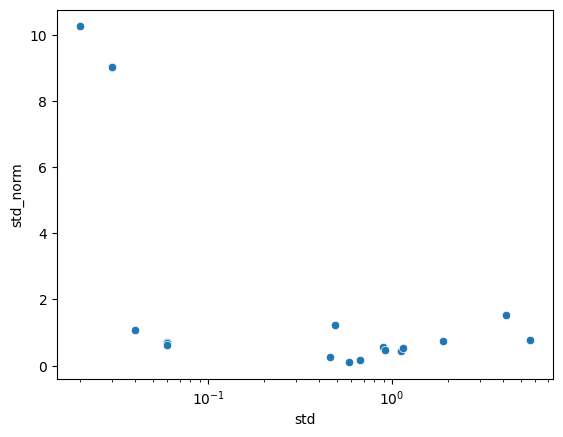

In [6]:
make(
    input_data,
    input_grouping,
    input_groups,
    input_preprocessing_config, 
    output_folder)

### What happens:
1. Read input_texas file
   1. set SUBJID as Index if not yet happened
   2. drop duplicates based on SUBJID and VISIT
2. Read grouping file as list of modules
3. If columns contain "_"
   1. Change columnname (test_test -> testTest) (in grouping[column_names] and data.columns)
   2. override original files with correct column names and save old data in csv.backup
4. For each data module (stalone, risk, charges)
   1. find common columns in input_data and grouping (totalChargesAccomm was written differently !!!)
   2. filter for columns
   3. calc missigness ratio for each column (1-count/total_number)
   4. drop column if missing at first visit > missigness_threshold
   5. (flag (?))=
   6. Create max_visit_dict with maximal visits for each module
5. Filter data to only keep max visit over all modules

6. Prepare Data Function (prepare_data -> helpers.py) with filtered data and max_visit_dict
      1. blabla
      2. For each module
         1. blabla .. for each VISIT
         2. copy visit data, drop visit column and make sure that all rows are present
      3. Rename each column except SUBJID (and VISIT but VISIT was dropped so why?) to column_VIS1
      4. If stalone module -> SA_column_VIS1
   1. Filter visit data (filter_data) based on missingness_threshold and variance_threshold
      1. Filter columns with only one unique value
      2. For each column compute variance (if int or float) or diversity if object
      3. Select cols > var_threshold
      4. calculate missingness (NA) and filter cols < missigness_t
      5. get overlapp of both col-sets and return filtered data and set of columns
   2. Define Auxiliary data (mask with missing values 0, not missing 1)
      1.  Impute missing values if stalone
          1.  LOOK AT Hivae types
          2.  real, pos, trincate_norm, gamma -> mean imputation
          3.  else mode imputation (Using first mode, if no mode 0)
          4.  fillnas with corresponding value
   3.  Create type dataframe (type, dim, nclass)
       1.  type => hivae_types of the respective column
       2.  dim => 1 if continous (real, pos, count), number_of_classes if categorical
       3.  nclass => number_of_classes if categorical, 0 if continuous
   4.  DO similar to 6.3 for module_data
       1.  add VIS1 and SA_ for columns and merge on SUBJID
   5.  Save Data for each module
       1.  visit_data -> _imp
       2.  missing_mask -> _mask
       3.  auxilary_data -> _aux
       4.  types -> types
       5.  raw_data_filteres -> raw
   6.  Concat all dfs for module vertically stacked and merge all dataframes by SUBJID
   7.  Return overall dataframe
   
7. Describe processed data (std, mean) -> desciptive_statisitcs.csv
   1. Create and Save scatterplot 

In [7]:
import pandas as pd
test = pd.read_csv(input_grouping)
data = pd.read_csv(input_data)
test["technical_group_name"].unique()

array(['stalone_var', 'riskModule', 'chargesModule'], dtype=object)

In [8]:
# Check that columns match
for i,j in zip(sorted(test.column_names), sorted(data.columns)[2:]):
    print(i, j, i==j)

admitWeekday admitWeekday True
discharge discharge True
ethnicity ethnicity True
illnessSeverity illnessSeverity True
lengthOfStay lengthOfStay True
patAge patAge True
patState patState True
patStatus patStatus True
race race True
riskMortality riskMortality True
sexCode sexCode True
totalCharges totalCharges True
totalChargesAccomm totalChargesAccomm True
totalChargesAncil totalChargesAncil True
totalNonCovCharges totalNonCovCharges True
totalNonCovChargesAccomm totalNonCovChargesAccomm True
totalNonCovChargesAncil totalNonCovChargesAncil True
typeOfAdmission typeOfAdmission True


In [9]:
for data_module in test["technical_group_name"].unique():
    columns = tuple(
        set(
            test.loc[
                test["technical_group_name"] == data_module,
                "column_names",
            ].tolist()
             + ["SUBJID", "VISIT"]
        )
    )
    columns = tuple(x for x in columns if x in data.columns)

In [19]:
data.nunique() > 1

SUBJID                       True
VISIT                       False
discharge                    True
typeOfAdmission              True
patState                     True
patStatus                    True
sexCode                      True
race                         True
ethnicity                    True
admitWeekday                 True
patAge                       True
riskMortality                True
illnessSeverity              True
lengthOfStay                 True
totalCharges                 True
totalNonCovCharges           True
totalChargesAccomm           True
totalNonCovChargesAccomm     True
totalChargesAncil            True
totalNonCovChargesAncil      True
dtype: bool